In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import cross_val_score

from xgboost import XGBClassifier

In [11]:
!ls

'archive (1) (1).zip'   german_credit_data.csv	 sample_data


In [13]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'archive (1) (1).zip', '.ipynb_checkpoints', 'german_credit_data.csv', 'sample_data']


In [15]:
!file german_credit_data.csv

german_credit_data.csv: Zip archive data, at least v4.5 to extract, compression method=deflate


In [16]:
!ls -lh german_credit_data.csv


-rw-r--r-- 1 root root 20K Jun  8 10:25 german_credit_data.csv


In [17]:
!head -5 german_credit_data.csv

K��-Ҽеa�@�*
�(Z*冮V�9�@>��|Q�#Yz�A���	���m����䆄�ű���nx���Jx��a�d��;����Z6o��y�J�j<�1k�1;�
2� L�H�dF�}��(��gW�pu}"�~�"���=:��a��յW8�</z~���$S�3?���������W* ��p�J"荨]���n~�v> �쪘�ـ����Ɯ��(�<��t�?*9w���D\,G�#�Ԡ0�?%��\u���Uu��,B��'�Y�m���Z���PB(���pD~��6i]�c�RWYu\2!L�v�/�͙Tk���_�
 ����6>�@�n�Yd/ĊA{�~����.�	4zJ�6��ѵ��k�,�ԃP��0^b���XА_K���]� �=���d��6	����å�7C�Ͳ���z#�ֵ�Rc�%�ٍ�p�sg;��^�h�d0����ȁ�	١����Lz-���@�0&R��E'd�m�/؁��4�U-e��6GT�0^X���ԾKWZ(i8��C��@����k#E^�L�f+ }��^0
��Z٩T�ck���8Y+5ņİ���&����æV


In [18]:
!file german_credit_data.csv

german_credit_data.csv: Zip archive data, at least v4.5 to extract, compression method=deflate


In [23]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [24]:
!ls -lh

total 24K
-rw-r--r-- 1 root root  20K Jun  8 10:42 'archive (1).zip'
drwxr-xr-x 1 root root 4.0K Jun  4 13:32  sample_data


In [25]:
from google.colab import files

uploaded = files.upload()

Saving german_credit_data.csv to german_credit_data.csv


In [27]:
!ls -lh

total 248K
-rw-r--r-- 1 root root  20K Jun  8 10:42 'archive (1).zip'
-rw-r--r-- 1 root root 222K Jun  8 10:45  german_credit_data.csv
drwxr-xr-x 1 root root 4.0K Jun  4 13:32  sample_data


In [28]:
import pandas as pd

df = pd.read_csv('german_credit_data.csv')

df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [29]:
print(df.shape)

print(df.info())

(1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 

In [30]:
print(df['target'].value_counts())

target
good    700
bad     300
Name: count, dtype: int64


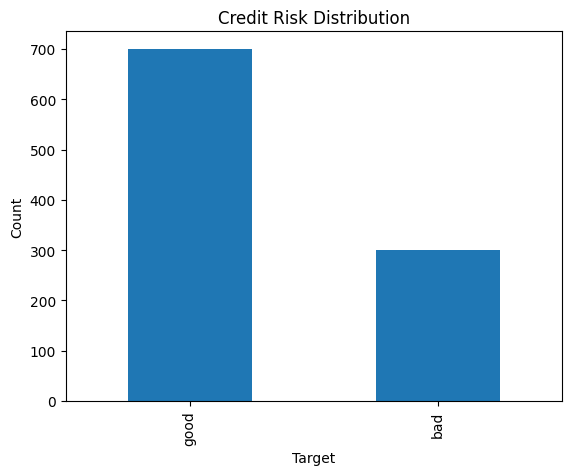

In [31]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title('Credit Risk Distribution')
plt.xlabel('Target')
plt.ylabel('Count')

plt.show()

In [32]:
df['target'] = df['target'].str.strip().str.lower()

df['target'] = df['target'].map({
    'good': 1,
    'bad': 0
})

print(df['target'].value_counts())


target
1    700
0    300
Name: count, dtype: int64


In [33]:
X = df.drop('target', axis=1)

y = df['target']

In [34]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)

(1000, 48)


In [35]:
X.columns = X.columns.str.replace('[', '', regex=False)
X.columns = X.columns.str.replace(']', '', regex=False)
X.columns = X.columns.str.replace('<', 'lt_', regex=False)
X.columns = X.columns.str.replace('>', 'gt_', regex=False)

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.795


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 32  27]
 [ 14 127]]


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.54      0.61        59
           1       0.82      0.90      0.86       141

    accuracy                           0.80       200
   macro avg       0.76      0.72      0.74       200
weighted avg       0.79      0.80      0.79       200



In [40]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=5
)

print(scores)

print("Average CV Score:",
      scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.75  0.76  0.76  0.74  0.755]
Average CV Score: 0.7529999999999999


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.775


In [43]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

feature_importance['Abs_Coefficient'] = abs(
    feature_importance['Coefficient']
)

feature_importance = feature_importance.sort_values(
    by='Abs_Coefficient',
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
10,credit_history_critical account/ other credits...,1.113844,1.113844
9,status_account_no checking account,1.103284,1.103284
47,is_foreign_worker_yes,-0.899088,0.899088
15,purpose_car (used),0.870447,0.870447
17,purpose_education,-0.778428,0.778428
39,other_installment_plans_none,0.707034,0.707034
34,secondary_obligor_guarantor,0.649045,0.649045
11,credit_history_delay in paying off in the past,0.643469,0.643469
14,purpose_car (new),-0.634318,0.634318
22,purpose_retraining,0.602463,0.602463
